In [1]:
!pip install kaggle


   ---- ----------------------------------- 1/9 [python-slugify]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   -------- ------------------------------- 2/9 [protobuf]
   ------------- -------------------------- 3/9 [mdurl]
   ----------------- ---------------------- 4/9 [markdown-it-py]
   ----------------- ---------------------- 4/9 [markdown-it-py]
   ----------------- ---------------------- 4/9 [markdown-it-py]
   ----------------- -------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import zipfile

# 1. Download dataset lewat Kaggle API resmi
!kaggle datasets download -d lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

# 2. Ekstrak file ZIP menggunakan Python murni (Menggantikan 'unzip')
zip_filename = "road-damage-dataset-potholes-cracks-and-manholes.zip"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall()  # Akan diekstrak ke folder 'road_damage_data'
print("Ekstrak selesai!")

# 3. Hapus file ZIP yang sudah tidak terpakai (Menggantikan 'rm')
if os.path.exists(zip_filename):
    os.remove(zip_filename)
    print(f"File {zip_filename} berhasil dihapus agar hemat ruang penyimpanan.")

Dataset URL: https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
License(s): MIT




  0%|          | 0.00/185M [00:00<?, ?B/s]
  1%|          | 1.00M/185M [00:00<01:48, 1.77MB/s]
  1%|          | 2.00M/185M [00:00<01:25, 2.25MB/s]
  2%|▏         | 3.00M/185M [00:01<01:22, 2.32MB/s]
  2%|▏         | 4.00M/185M [00:01<01:17, 2.45MB/s]
  3%|▎         | 5.00M/185M [00:02<01:18, 2.41MB/s]
  3%|▎         | 6.00M/185M [00:02<01:18, 2.39MB/s]
  4%|▍         | 7.00M/185M [00:03<01:15, 2.47MB/s]
  4%|▍         | 8.00M/185M [00:03<01:19, 2.32MB/s]
  5%|▍         | 9.00M/185M [00:03<01:16, 2.40MB/s]
  5%|▌         | 10.0M/185M [00:04<01:14, 2.45MB/s]
  6%|▌         | 11.0M/185M [00:04<01:16, 2.40MB/s]
  6%|▋         | 12.0M/185M [00:05<01:16, 2.38MB/s]
  7%|▋         | 13.0M/185M [00:05<01:14, 2.41MB/s]
  8%|▊         | 14.0M/185M [00:06<01:16, 2.35MB/s]
  8%|▊         | 15.0M/185M [00:06<01:14, 2.40MB/s]
  9%|▊         | 16.0M/185M [00:07<01:17, 2.30MB/s]
  9%|▉         | 17.0M/185M [00:07<01:14, 2.37MB/s]
 10%|▉         | 18.0M/185M [00:07<01:10, 2.48MB/s]
 10%|█         | 19.

Ekstrak selesai!
File road-damage-dataset-potholes-cracks-and-manholes.zip berhasil dihapus agar hemat ruang penyimpanan.


Total objek  : 4737

Lebar objek (px):
  min    : 2.0
  median : 62.0
  mean   : 80.3
  p75    : 94.0
  max    : 640.0

Tinggi objek (px):
  min    : 0.0
  median : 28.0
  mean   : 37.9
  p75    : 48.0
  max    : 359.0

Per kelas:
  pothole  (1261 obj) — w median: 45.0px, h median: 20.0px
  crack    (2519 obj) — w median: 80.0px, h median: 43.0px
  manhole  ( 957 obj) — w median: 55.0px, h median: 19.0px


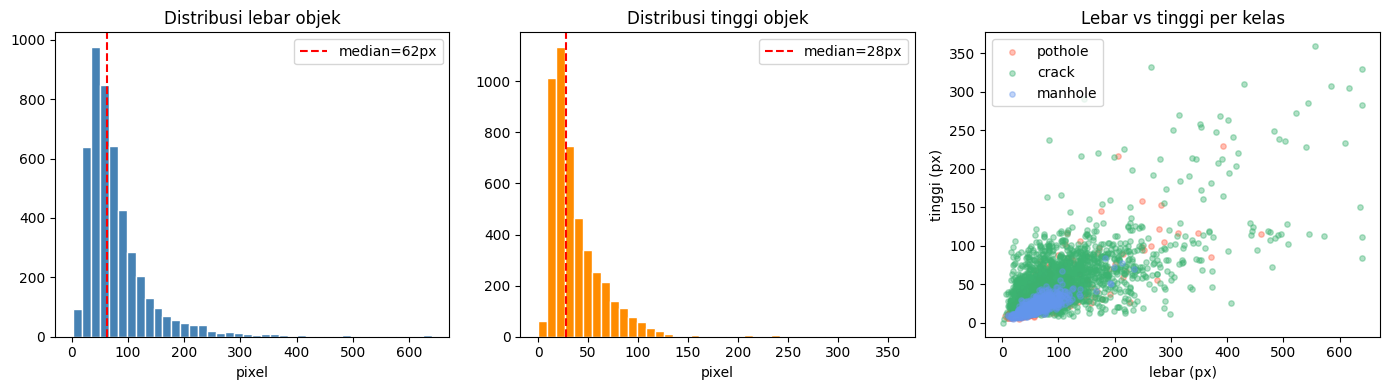

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Konstanta resolusi gambar (dari README: 640×360)
# -------------------------------------------------------------------
IMG_W = 640
IMG_H = 360

NAMA_KELAS = {0: 'pothole', 1: 'crack', 2: 'manhole'}

# -------------------------------------------------------------------
# Fungsi baca label YOLO
# Format: kelas cx cy w h (semua normalized)
# -------------------------------------------------------------------
def baca_yolo(path_txt):
    """
    Membaca file label YOLO dan mengembalikan list dict berisi
    koordinat pixel absolut (x1,y1,x2,y2) dan kelas objek.
    
    Konversi:
      cx_pixel = cx_norm * IMG_W
      x1_pixel = (cx - w/2) * IMG_W
    """
    hasil = []
    if not os.path.exists(path_txt):
        return hasil
    with open(path_txt) as f:
        for baris in f:
            parts = baris.strip().split()
            if len(parts) != 5:
                continue
            kelas = int(parts[0])
            cx = float(parts[1]) * IMG_W
            cy = float(parts[2]) * IMG_H
            w  = float(parts[3]) * IMG_W
            h  = float(parts[4]) * IMG_H
            hasil.append({
                'kelas': kelas,
                'x1': int(cx - w/2), 'y1': int(cy - h/2),
                'x2': int(cx + w/2), 'y2': int(cy + h/2),
                'w_px': w, 'h_px': h
            })
    return hasil

# -------------------------------------------------------------------
# Kumpulkan statistik dari SEMUA file label
# -------------------------------------------------------------------
semua_w, semua_h, semua_kelas = [], [], []

for path_label in glob.glob('data/labels-YOLO/*.txt'):
    for obj in baca_yolo(path_label):
        semua_w.append(obj['w_px'])
        semua_h.append(obj['h_px'])
        semua_kelas.append(obj['kelas'])

semua_w = np.array(semua_w)
semua_h = np.array(semua_h)

# -------------------------------------------------------------------
# Cetak ringkasan statistik
# -------------------------------------------------------------------
print(f"Total objek  : {len(semua_w)}")
print(f"\nLebar objek (px):")
print(f"  min    : {semua_w.min():.1f}")
print(f"  median : {np.median(semua_w):.1f}")
print(f"  mean   : {semua_w.mean():.1f}")
print(f"  p75    : {np.percentile(semua_w, 75):.1f}")
print(f"  max    : {semua_w.max():.1f}")

print(f"\nTinggi objek (px):")
print(f"  min    : {semua_h.min():.1f}")
print(f"  median : {np.median(semua_h):.1f}")
print(f"  mean   : {semua_h.mean():.1f}")
print(f"  p75    : {np.percentile(semua_h, 75):.1f}")
print(f"  max    : {semua_h.max():.1f}")

print(f"\nPer kelas:")
for k, nama in NAMA_KELAS.items():
    idx = np.where(np.array(semua_kelas) == k)[0]
    if len(idx) == 0:
        continue
    w_k = semua_w[idx]
    h_k = semua_h[idx]
    print(f"  {nama:8s} ({len(idx):4d} obj) — "
          f"w median: {np.median(w_k):.1f}px, "
          f"h median: {np.median(h_k):.1f}px")

# -------------------------------------------------------------------
# Visualisasi distribusi
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histogram lebar
axes[0].hist(semua_w, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(np.median(semua_w), color='red', linestyle='--', label=f'median={np.median(semua_w):.0f}px')
axes[0].set_title('Distribusi lebar objek')
axes[0].set_xlabel('pixel'); axes[0].legend()

# histogram tinggi
axes[1].hist(semua_h, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(np.median(semua_h), color='red', linestyle='--', label=f'median={np.median(semua_h):.0f}px')
axes[1].set_title('Distribusi tinggi objek')
axes[1].set_xlabel('pixel'); axes[1].legend()

# scatter w vs h, warna per kelas
warna_kelas = {0: 'tomato', 1: 'mediumseagreen', 2: 'cornflowerblue'}
for k, nama in NAMA_KELAS.items():
    idx = np.where(np.array(semua_kelas) == k)[0]
    axes[2].scatter(semua_w[idx], semua_h[idx],
                    c=warna_kelas[k], label=nama, alpha=0.4, s=15)
axes[2].set_title('Lebar vs tinggi per kelas')
axes[2].set_xlabel('lebar (px)'); axes[2].set_ylabel('tinggi (px)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
import glob

# ambil file gambar pertama yang tersedia
semua_gambar = sorted(glob.glob('data/images/*.jpg'))
print(f"Total gambar: {len(semua_gambar)}")
print(f"Contoh nama file: {semua_gambar[:5]}")

# pakai yang pertama untuk visualisasi
path_contoh = semua_gambar[0]
print(f"\nMenggunakan: {path_contoh}")

img_bgr, gray, enhanced = preprocess_gambar(path_contoh)

Total gambar: 2009
Contoh nama file: ['data/images\\20250216_164325.jpg', 'data/images\\20250216_164521.jpg', 'data/images\\20250216_164541.jpg', 'data/images\\20250219_164649.jpg', 'data/images\\20250219_164714.jpg']

Menggunakan: data/images\20250216_164325.jpg


In [7]:
# cek apakah file label pasangannya ada
def cari_label(path_img):
    nama = os.path.splitext(os.path.basename(path_img))[0]
    return f'data/labels-YOLO/{nama}.txt'

# cek 5 gambar pertama
for path_img in semua_gambar[:5]:
    path_lbl = cari_label(path_img)
    ada = os.path.exists(path_lbl)
    print(f"{os.path.basename(path_img)} → label {'ADA' if ada else 'TIDAK ADA'}")

# hitung total yang punya pasangan label
punya_label = [p for p in semua_gambar if os.path.exists(cari_label(p))]
print(f"\nGambar dengan label : {len(punya_label)}")
print(f"Gambar tanpa label  : {len(semua_gambar) - len(punya_label)}")

20250216_164325.jpg → label ADA
20250216_164521.jpg → label ADA
20250216_164541.jpg → label ADA
20250219_164649.jpg → label ADA
20250219_164714.jpg → label ADA

Gambar dengan label : 2009
Gambar tanpa label  : 0


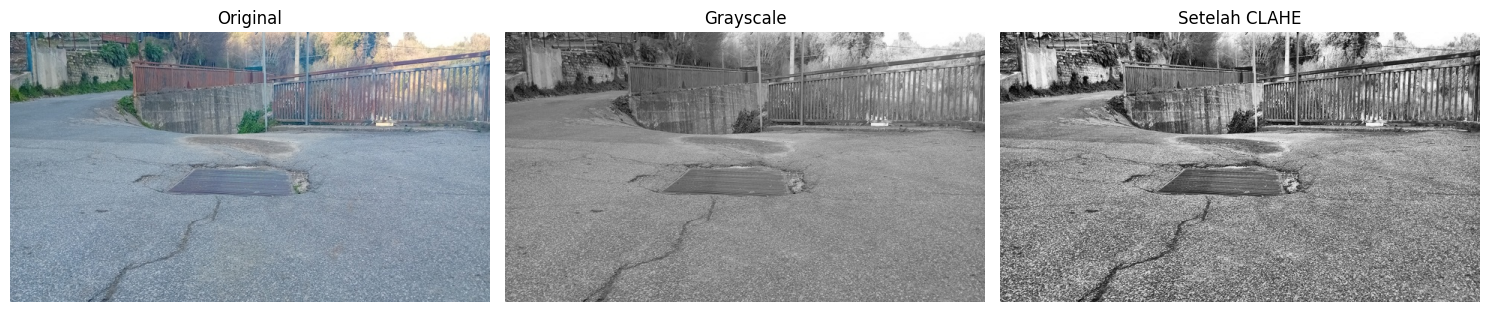

Estimasi jumlah patch per gambar:

  small (pothole/manhole)        →  399 patch
  medium (crack)                 →  168 patch
  TOTAL                          →  567 patch per gambar


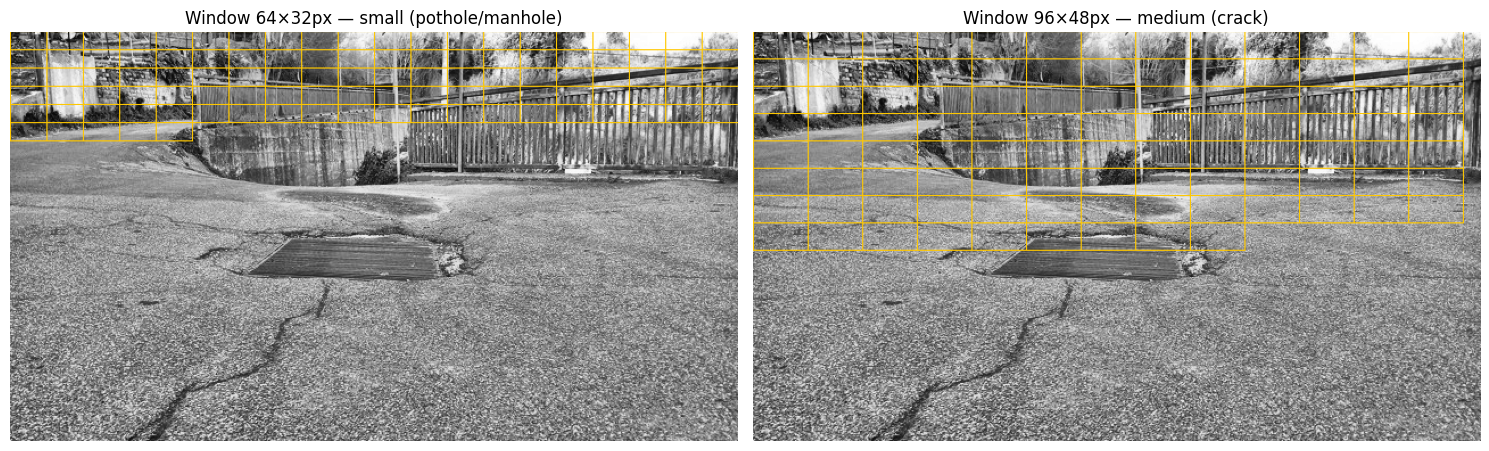

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ── konstanta ──────────────────────────────────────────────────────
IMG_W, IMG_H = 640, 360
NAMA_KELAS   = {0: 'pothole', 1: 'crack', 2: 'manhole'}
WINDOW_CONFIGS = [
    {'win_w': 64,  'win_h': 32,  'stride_x': 32, 'stride_y': 16,
     'label': 'small (pothole/manhole)'},
    {'win_w': 96,  'win_h': 48,  'stride_x': 48, 'stride_y': 24,
     'label': 'medium (crack)'},
]

# ── fungsi preprocessing ───────────────────────────────────────────
def ke_grayscale(img_bgr):
    B = img_bgr[:, :, 0].astype(np.float32)
    G = img_bgr[:, :, 1].astype(np.float32)
    R = img_bgr[:, :, 2].astype(np.float32)
    return (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

def clahe_manual(gray, clip_limit=2.0, tile_size=8):
    clahe = cv2.createCLAHE(clipLimit=clip_limit,
                             tileGridSize=(tile_size, tile_size))
    return clahe.apply(gray)

def preprocess_gambar(path_img):
    img_bgr = cv2.imread(path_img)
    if img_bgr is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path_img}")
    gray     = ke_grayscale(img_bgr)
    enhanced = clahe_manual(gray)
    return img_bgr, gray, enhanced

# ── fungsi sliding window ──────────────────────────────────────────
def sliding_window(img_gray, win_w, win_h, stride_x, stride_y):
    img_h, img_w = img_gray.shape
    y = 0
    while y + win_h <= img_h:
        x = 0
        while x + win_w <= img_w:
            yield (x, y, img_gray[y:y+win_h, x:x+win_w])
            x += stride_x
        y += stride_y

def hitung_jumlah_window(img_h, img_w, win_w, win_h, stride_x, stride_y):
    n_x = (img_w - win_w) // stride_x + 1
    n_y = (img_h - win_h) // stride_y + 1
    return n_x * n_y

def visualisasi_sliding_window(img_bgr, img_gray, config, max_tampil=80):
    vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    count = 0
    for x, y, patch in sliding_window(img_gray,
                                       config['win_w'], config['win_h'],
                                       config['stride_x'], config['stride_y']):
        cv2.rectangle(vis, (x, y),
                      (x + config['win_w'], y + config['win_h']),
                      (0, 200, 255), 1)
        count += 1
        if count >= max_tampil:
            break
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

# ── ambil gambar ───────────────────────────────────────────────────
semua_gambar = sorted(glob.glob('data/images/*.jpg'))
path_contoh  = semua_gambar[0]
img_bgr, gray, enhanced = preprocess_gambar(path_contoh)

# ── visualisasi preprocessing ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[2].imshow(enhanced, cmap='gray')
axes[2].set_title('Setelah CLAHE')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# ── estimasi patch ─────────────────────────────────────────────────
print("Estimasi jumlah patch per gambar:\n")
total = 0
for cfg in WINDOW_CONFIGS:
    n = hitung_jumlah_window(IMG_H, IMG_W,
                              cfg['win_w'], cfg['win_h'],
                              cfg['stride_x'], cfg['stride_y'])
    print(f"  {cfg['label']:30s} → {n:4d} patch")
    total += n
print(f"  {'TOTAL':30s} → {total:4d} patch per gambar")

# ── visualisasi sliding window ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, cfg in enumerate(WINDOW_CONFIGS):
    vis = visualisasi_sliding_window(img_bgr, enhanced, cfg)
    axes[i].imshow(vis)
    axes[i].set_title(f"Window {cfg['win_w']}×{cfg['win_h']}px — {cfg['label']}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Ada satu masalah yang perlu diperhatikan — gambar ini punya background berupa pagar dan tembok di bagian atas. Artinya banyak patch dari area atas gambar bukan aspal sama sekali. Ini akan jadi noise untuk classifier kita nanti — kita perlu cara untuk mem-filter patch "bukan aspal". Tapi itu kita tangani di tahap classifier, bukan sekarang.


In [10]:
def hitung_gradient(patch):
    """
    Hitung magnitudo dan arah gradient di setiap pixel.
    
    Gradient mengukur SEBERAPA CEPAT intensitas berubah
    dan KE ARAH MANA. Di tepi retak, intensitas berubah
    tajam → gradient besar. Di aspal mulus, perubahan
    lambat → gradient kecil.
    
    Kita pakai kernel Sobel 1D sederhana: [-1, 0, 1]
    
    Untuk gradient horizontal (Gx):
      Gx[i,j] = pixel[i, j+1] - pixel[i, j-1]
      → mendeteksi perubahan ke kiri-kanan
    
    Untuk gradient vertikal (Gy):
      Gy[i,j] = pixel[i+1, j] - pixel[i-1, j]
      → mendeteksi perubahan ke atas-bawah
    
    Magnitudo: sqrt(Gx² + Gy²)
    Arah     : arctan(Gy / Gx) dalam derajat
    """
    patch_f = patch.astype(np.float32)

    # padding reflect: isi tepi dengan mirror dari isi patch
    # agar pixel di border juga punya tetangga kiri/kanan/atas/bawah
    p = np.pad(patch_f, 1, mode='reflect')

    Gx = p[1:-1, 2:] - p[1:-1, :-2]   # selisih kanan - kiri
    Gy = p[2:, 1:-1] - p[:-2, 1:-1]   # selisih bawah - atas

    magnitudo = np.sqrt(Gx**2 + Gy**2)
    arah      = np.degrees(np.arctan2(Gy, Gx)) % 180  # lipat ke 0-180°
    #   kenapa % 180? HOG tidak peduli arah tepi ke kiri atau kanan —
    #   gradient 0° dan 180° adalah tepi yang sama, cuma tanda berbeda.

    return magnitudo, arah


def hog_patch(patch, cell_size=8, n_bins=9):
    """
    HOG = Histogram of Oriented Gradients.
    
    Ide dasarnya: daripada menyimpan gradient tiap pixel
    (terlalu banyak data, sensitif noise), kita rangkum
    distribusi ARAH gradient dalam area kecil (cell).
    
    Langkah-langkah:
    
    1. Hitung gradient tiap pixel (magnitudo + arah)
    
    2. Bagi patch jadi cell berukuran cell_size × cell_size pixel
    
    3. Untuk tiap cell, buat histogram 9 bin (0°,20°,40°,...,160°)
       Setiap pixel "menyumbang" ke bin sesuai arahnya,
       dengan berat = magnitudonya.
       
       Contoh: pixel dengan arah 35° dan magnitudo 50
         → masuk ke bin 20°-40° dengan bobot 50
       
    4. Gabungkan semua histogram cell → satu vektor fitur
    
    Kenapa HOG bagus untuk crack/pothole?
    Crack punya orientasi tepi yang khas (horizontal/diagonal).
    Pothole punya tepi melingkar. HOG menangkap pola ini.
    """
    # resize patch ke ukuran yang habis dibagi cell_size
    h_baru = (patch.shape[0] // cell_size) * cell_size
    w_baru = (patch.shape[1] // cell_size) * cell_size
    patch_r = cv2.resize(patch, (w_baru, h_baru),
                         interpolation=cv2.INTER_LINEAR)

    magnitudo, arah = hitung_gradient(patch_r)

    n_cell_y = h_baru // cell_size
    n_cell_x = w_baru // cell_size
    bins     = np.linspace(0, 180, n_bins + 1)  # [0,20,40,...,180]

    histograms = []
    for cy in range(n_cell_y):
        for cx in range(n_cell_x):
            # crop satu cell
            y0, y1 = cy*cell_size, (cy+1)*cell_size
            x0, x1 = cx*cell_size, (cx+1)*cell_size
            mag_cell = magnitudo[y0:y1, x0:x1].ravel()
            dir_cell = arah[y0:y1, x0:x1].ravel()

            # buat histogram berbobot magnitudo
            hist, _ = np.histogram(dir_cell, bins=bins, weights=mag_cell)
            
            # normalisasi per cell agar tidak sensitif kecerahan
            norm = np.linalg.norm(hist)
            if norm > 0:
                hist = hist / norm

            histograms.append(hist)

    return np.concatenate(histograms)  # vektor 1D


### 5b. LBP (Local Binary Pattern)

def lbp_patch(patch, radius=1, n_points=8):
    """
    LBP = Local Binary Pattern.
    
    Ide: untuk setiap pixel pusat, bandingkan nilainya
    dengan tetangga-tetangganya di sekeliling (radius r).
    
    Proses per pixel:
      1. Ambil n_points tetangga melingkar di radius r
         (posisinya dihitung dengan trigonometri)
      2. Kalau tetangga ≥ pusat → bit = 1, kalau < → bit = 0
      3. Rangkai n_points bit → bilangan biner → desimal
         Contoh: [1,1,0,1,0,0,1,0] → 11010010₂ → 210
    
    Hasilnya: setiap pixel punya "kode tekstur" 0-255.
    
    Kita tidak simpan per pixel, tapi buat histogram
    dari semua kode → distribusi tekstur patch.
    
    Kenapa LBP bagus?
    Invariant terhadap monotonic intensity change —
    kalau seluruh gambar jadi lebih terang/gelap,
    pola relatif antar pixel tetap sama.
    Crack punya pola LBP yang berbeda dari aspal halus.
    """
    patch_f = patch.astype(np.float32)
    H, W    = patch_f.shape
    lbp_img = np.zeros((H, W), dtype=np.float32)

    for i in range(H):
        for j in range(W):
            pusat = patch_f[i, j]
            kode  = 0
            for k in range(n_points):
                # posisi tetangga ke-k di lingkaran radius r
                sudut = 2 * np.pi * k / n_points
                ni    = i - radius * np.sin(sudut)   # baris (y turun ke bawah)
                nj    = j + radius * np.cos(sudut)   # kolom

                # interpolasi bilinear untuk posisi non-integer
                ni0, nj0 = int(np.floor(ni)), int(np.floor(nj))
                ni1, nj1 = ni0 + 1, nj0 + 1

                # clamp agar tidak keluar batas patch
                ni0 = np.clip(ni0, 0, H-1)
                ni1 = np.clip(ni1, 0, H-1)
                nj0 = np.clip(nj0, 0, W-1)
                nj1 = np.clip(nj1, 0, W-1)

                # bobot interpolasi
                dy = ni - np.floor(ni)
                dx = nj - np.floor(nj)
                nilai_tetangga = (
                    patch_f[ni0, nj0] * (1-dy) * (1-dx) +
                    patch_f[ni0, nj1] * (1-dy) *    dx  +
                    patch_f[ni1, nj0] *    dy  * (1-dx) +
                    patch_f[ni1, nj1] *    dy  *    dx
                )

                if nilai_tetangga >= pusat:
                    kode |= (1 << k)  # set bit ke-k

            lbp_img[i, j] = kode

    # histogram dari kode LBP
    hist, _ = np.histogram(lbp_img.ravel(), bins=256,
                            range=(0, 256), density=True)
    return hist.astype(np.float32)


### 5c. GLCM (Gray-Level Co-occurrence Matrix)

def glcm_patch(patch, distances=[1], angles=[0, 45, 90, 135], levels=32):
    """
    GLCM = Gray-Level Co-occurrence Matrix.
    
    Ide: hitung seberapa sering dua pixel yang berjarak
    tertentu (distance) dengan arah tertentu (angle)
    punya kombinasi intensitas (i, j).
    
    Contoh sederhana (distance=1, angle=0° = horizontal):
      Lihat setiap pasangan pixel (kiri, kanan).
      Kalau pixel kiri = 3 dan kanan = 5 → increment M[3,5]
      Ulangi untuk semua pasangan → matrix levels × levels
    
    Dari matrix ini kita ekstrak 4 statistik Haralick:
    
    1. Contrast   = Σ (i-j)² × M[i,j]
       Mengukur variasi lokal. Tinggi untuk tekstur kasar (crack).
    
    2. Homogeneity = Σ M[i,j] / (1 + |i-j|)
       Kebalikan contrast. Tinggi untuk tekstur halus (aspal mulus).
    
    3. Energy     = Σ M[i,j]²  (juga disebut Angular Second Moment)
       Mengukur keseragaman. Tinggi kalau pola tekstur berulang.
    
    4. Correlation = mengukur linearitas hubungan antar pixel.
    
    Dihitung untuk semua kombinasi distance × angle → di-average.
    """
    # kurangi level warna agar matrix tidak terlalu sparse
    # dari 256 level ke 'levels' level
    factor = 256 / levels
    p = np.floor(patch.astype(np.float32) / factor).astype(np.int32)
    p = np.clip(p, 0, levels - 1)
    H, W = p.shape

    # arah offset (dy, dx) untuk setiap angle
    offsets = {
        0:   (0,  1),
        45:  (-1, 1),
        90:  (-1, 0),
        135: (-1,-1),
    }

    fitur_semua = []
    for dist in distances:
        for angle in angles:
            dy, dx = offsets[angle]
            dy, dx = dy * dist, dx * dist

            # bangun GLCM
            M = np.zeros((levels, levels), dtype=np.float64)
            for i in range(max(0, -dy), min(H, H - dy)):
                for j in range(max(0, -dx), min(W, W - dx)):
                    ni, nj = i + dy, j + dx
                    if 0 <= ni < H and 0 <= nj < W:
                        M[p[i, j], p[ni, nj]] += 1

            # simetriskan dan normalisasi
            M = M + M.T
            total = M.sum()
            if total > 0:
                M /= total

            # hitung statistik Haralick
            idx = np.arange(levels)
            I, J = np.meshgrid(idx, idx, indexing='ij')

            contrast     = np.sum(M * (I - J)**2)
            homogeneity  = np.sum(M / (1 + np.abs(I - J)))
            energy       = np.sum(M**2)
            mu_i = np.sum(I * M)
            mu_j = np.sum(J * M)
            std_i = np.sqrt(np.sum(M * (I - mu_i)**2) + 1e-8)
            std_j = np.sqrt(np.sum(M * (J - mu_j)**2) + 1e-8)
            correlation  = np.sum(M * (I - mu_i) * (J - mu_j)) / (std_i * std_j)

            fitur_semua.extend([contrast, homogeneity, energy, correlation])

    return np.array(fitur_semua, dtype=np.float32)

In [11]:
def ekstrak_fitur_patch(patch):
    """
    Gabungkan HOG + LBP + GLCM + statistik global
    menjadi satu vektor fitur untuk satu patch.
    
    Statistik global (mean, std, skewness, kurtosis):
    Fitur paling sederhana — distribusi intensitas pixel.
    Pothole cenderung lebih gelap (cekungan = bayangan).
    Manhole cenderung seragam (besi cor, tekstur konsisten).
    """
    # resize patch ke ukuran standar sebelum ekstraksi
    p = cv2.resize(patch, (64, 32), interpolation=cv2.INTER_LINEAR)

    f_hog  = hog_patch(p, cell_size=8, n_bins=9)
    f_lbp  = lbp_patch(p, radius=1, n_points=8)
    f_glcm = glcm_patch(p, distances=[1], angles=[0,45,90,135], levels=32)

    # statistik global
    px = p.astype(np.float32) / 255.0
    mean_  = np.mean(px)
    std_   = np.std(px)
    # skewness: simetri distribusi — (mean - median) / std
    skew_  = (mean_ - np.median(px)) / (std_ + 1e-8)
    # kurtosis: ketajaman puncak distribusi
    kurt_  = np.mean((px - mean_)**4) / (std_**4 + 1e-8)
    f_stat = np.array([mean_, std_, skew_, kurt_], dtype=np.float32)

    return np.concatenate([f_hog, f_lbp, f_glcm, f_stat])


# ── test pada satu patch ───────────────────────────────────────────
# ambil satu patch dari sliding window pertama
for x, y, patch in sliding_window(enhanced,
                                   WINDOW_CONFIGS[0]['win_w'],
                                   WINDOW_CONFIGS[0]['win_h'],
                                   WINDOW_CONFIGS[0]['stride_x'],
                                   WINDOW_CONFIGS[0]['stride_y']):
    fitur = ekstrak_fitur_patch(patch)
    print(f"Patch ({x},{y}) ukuran {patch.shape}")
    print(f"  HOG  : {hog_patch(cv2.resize(patch,(64,32))).shape[0]} fitur")
    print(f"  LBP  : {lbp_patch(cv2.resize(patch,(64,32))).shape[0]} fitur")
    print(f"  GLCM : {glcm_patch(cv2.resize(patch,(64,32))).shape[0]} fitur")
    print(f"  Stat : 4 fitur")
    print(f"  TOTAL: {fitur.shape[0]} fitur")
    break  # cukup satu patch untuk verifikasi

Patch (0,0) ukuran (32, 64)
  HOG  : 288 fitur
  LBP  : 256 fitur
  GLCM : 16 fitur
  Stat : 4 fitur
  TOTAL: 564 fitur


Verifikasi dimensi berhasil — 564 fitur per patch, breakdown-nya masuk akal semua.
Sekarang ada satu masalah praktis yang perlu kita selesaikan sebelum lanjut ke training: LBP dari scratch terlalu lambat untuk 2009 gambar × 567 patch. Mari kita hitung dulu bebannya:


In [12]:
import time

# ukur waktu ekstraksi SATU patch
for x, y, patch in sliding_window(enhanced,
                                   WINDOW_CONFIGS[0]['win_w'],
                                   WINDOW_CONFIGS[0]['win_h'],
                                   WINDOW_CONFIGS[0]['stride_x'],
                                   WINDOW_CONFIGS[0]['stride_y']):
    p = cv2.resize(patch, (64, 32), interpolation=cv2.INTER_LINEAR)
    
    t0 = time.time()
    _ = lbp_patch(p)
    t_lbp = time.time() - t0
    
    t0 = time.time()
    _ = hog_patch(p)
    t_hog = time.time() - t0
    
    t0 = time.time()
    _ = glcm_patch(p)
    t_glcm = time.time() - t0
    
    print(f"Waktu per patch:")
    print(f"  HOG  : {t_hog*1000:.2f} ms")
    print(f"  LBP  : {t_lbp*1000:.2f} ms")
    print(f"  GLCM : {t_glcm*1000:.2f} ms")
    
    total_patch = 2009 * 567
    t_total_estimasi = (t_lbp + t_hog + t_glcm) * total_patch
    print(f"\nEstimasi total ({total_patch:,} patch):")
    print(f"  {t_total_estimasi/60:.1f} menit")
    break

Waktu per patch:
  HOG  : 1.08 ms
  LBP  : 502.36 ms
  GLCM : 4.49 ms

Estimasi total (1,139,103 patch):
  9643.3 menit


In [13]:
def lbp_patch_fast(patch, radius=1, n_points=8):
    """
    LBP vektorisasi — hasil identik dengan versi lambat,
    tapi semua operasi per-pixel diganti operasi array NumPy.
    
    Kuncinya: kita proses SATU tetangga untuk SEMUA pixel sekaligus,
    bukan SEMUA tetangga untuk SATU pixel sekaligus.
    
    Untuk setiap k dari 0..n_points-1:
      1. Hitung koordinat float (ni, nj) untuk semua pixel
         menggunakan broadcasting — satu operasi untuk seluruh grid
      2. Lakukan interpolasi bilinear vectorized:
         ambil 4 sudut sekaligus dengan array indexing
      3. Bandingkan dengan array pusat → array boolean
      4. Akumulasi ke lbp_img dengan bitshift
    
    Loop Python hanya 8x (jumlah tetangga), bukan H×W×8.
    """
    patch_f = patch.astype(np.float32)
    H, W    = patch_f.shape
    lbp_img = np.zeros((H, W), dtype=np.uint8)

    # grid koordinat semua pixel — shape (H, W)
    rows, cols = np.mgrid[0:H, 0:W]

    for k in range(n_points):
        sudut = 2 * np.pi * k / n_points

        # koordinat float tetangga untuk SEMUA pixel sekaligus
        ni = rows - radius * np.sin(sudut)   # shape (H, W)
        nj = cols + radius * np.cos(sudut)   # shape (H, W)

        # floor → indeks sudut kiri atas interpolasi
        ni0 = np.floor(ni).astype(np.int32)
        nj0 = np.floor(nj).astype(np.int32)
        ni1 = ni0 + 1
        nj1 = nj0 + 1

        # clamp semua indeks sekaligus
        ni0 = np.clip(ni0, 0, H-1)
        ni1 = np.clip(ni1, 0, H-1)
        nj0 = np.clip(nj0, 0, W-1)
        nj1 = np.clip(nj1, 0, W-1)

        # bobot interpolasi
        dy = ni - np.floor(ni)   # shape (H, W)
        dx = nj - np.floor(nj)

        # interpolasi bilinear vectorized — semua pixel sekaligus
        nilai_tetangga = (
            patch_f[ni0, nj0] * (1-dy) * (1-dx) +
            patch_f[ni0, nj1] * (1-dy) *    dx  +
            patch_f[ni1, nj0] *    dy  * (1-dx) +
            patch_f[ni1, nj1] *    dy  *    dx
        )

        # bandingkan dengan pusat — hasilkan array boolean
        bit = (nilai_tetangga >= patch_f).astype(np.uint8)

        # set bit ke-k untuk semua pixel sekaligus
        lbp_img |= (bit << k)

    hist, _ = np.histogram(lbp_img.ravel(), bins=256,
                            range=(0, 256), density=True)
    return hist.astype(np.float32)

In [14]:
# ambil satu patch untuk perbandingan
for x, y, patch in sliding_window(enhanced,
                                   WINDOW_CONFIGS[0]['win_w'],
                                   WINDOW_CONFIGS[0]['win_h'],
                                   WINDOW_CONFIGS[0]['stride_x'],
                                   WINDOW_CONFIGS[0]['stride_y']):
    p = cv2.resize(patch, (64, 32), interpolation=cv2.INTER_LINEAR)

    # bandingkan hasil
    hasil_lama  = lbp_patch(p)
    hasil_baru  = lbp_patch_fast(p)
    selisih_max = np.max(np.abs(hasil_lama - hasil_baru))
    print(f"Selisih maksimum hasil lama vs baru: {selisih_max:.2e}")
    print(f"(Harus mendekati 0 — kalau > 1e-5 ada bug)\n")

    # bandingkan kecepatan
    t0 = time.time()
    for _ in range(20): lbp_patch(p)
    t_lama = (time.time() - t0) / 20

    t0 = time.time()
    for _ in range(200): lbp_patch_fast(p)
    t_baru = (time.time() - t0) / 200

    print(f"LBP lama  : {t_lama*1000:.2f} ms/patch")
    print(f"LBP baru  : {t_baru*1000:.2f} ms/patch")
    print(f"Speedup   : {t_lama/t_baru:.0f}x")

    total_patch = 2009 * 567
    t_estimasi_baru = (t_baru + 1.08/1000 + 4.49/1000) * total_patch
    print(f"\nEstimasi total baru: {t_estimasi_baru/60:.1f} menit")
    break

Selisih maksimum hasil lama vs baru: 0.00e+00
(Harus mendekati 0 — kalau > 1e-5 ada bug)

LBP lama  : 414.29 ms/patch
LBP baru  : 1.19 ms/patch
Speedup   : 349x

Estimasi total baru: 128.3 menit


128 menit masih agak lama, tapi kita bisa potong lagi dengan satu strategi: tidak semua 2009 gambar perlu diproses. Kita sample sebagian saja untuk training, sisanya untuk evaluasi. Tapi itu keputusan nanti.Sekarang update ekstrak_fitur_patch pakai versi fast, lalu kita masuk ke tahap paling penting sebelum training: memberi label pada setiap patch.

Ground truth boxes: 9
  manhole  → (203,173) - (394,225) [191×52px]
  pothole  → (373,179) - (401,220) [28×41px]
  pothole  → (166,185) - (198,205) [32×20px]
  pothole  → (231,171) - (264,187) [33×16px]
  crack    → (254,225) - (286,257) [32×32px]
  crack    → (100,283) - (231,357) [131×74px]
  crack    → (216,245) - (255,290) [39×45px]
  crack    → (371,182) - (419,221) [48×39px]
  crack    → (275,168) - (372,182) [97×14px]


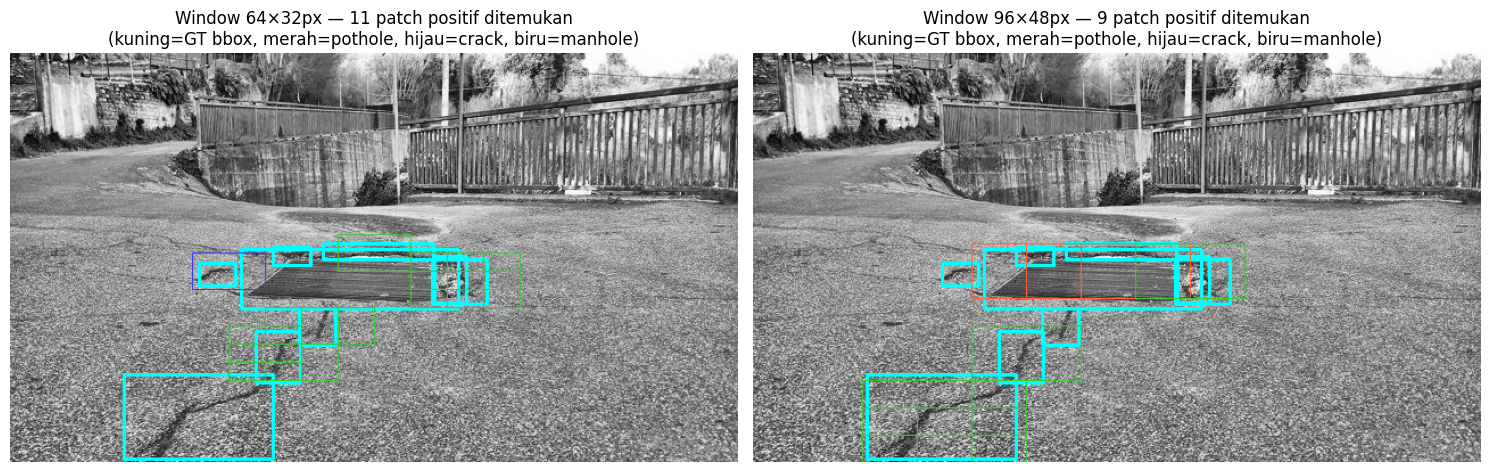

In [15]:
def hitung_iou(box_a, box_b):
    """
    Hitung IoU antara dua bounding box.
    
    Format box: (x1, y1, x2, y2) — koordinat pixel absolut.
    
    Cara hitung irisan:
      Irisan ada kalau kedua box overlap di KEDUA sumbu.
      x irisan: dari max(x1_a, x1_b) sampai min(x2_a, x2_b)
      y irisan: dari max(y1_a, y1_b) sampai min(y2_a, y2_b)
      
      Kalau max > min di salah satu sumbu → tidak overlap → irisan = 0
    
    Luas gabungan = luas A + luas B - luas irisan
    (irisan dihitung dua kali kalau pakai luas A + luas B saja)
    """
    # koordinat irisan
    ix1 = max(box_a[0], box_b[0])
    iy1 = max(box_a[1], box_b[1])
    ix2 = min(box_a[2], box_b[2])
    iy2 = min(box_a[3], box_b[3])

    # luas irisan — 0 kalau tidak overlap
    lebar_irisan  = max(0, ix2 - ix1)
    tinggi_irisan = max(0, iy2 - iy1)
    luas_irisan   = lebar_irisan * tinggi_irisan

    if luas_irisan == 0:
        return 0.0

    luas_a       = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    luas_b       = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    luas_gabungan = luas_a + luas_b - luas_irisan

    return luas_irisan / luas_gabungan


def label_patch(x, y, win_w, win_h, gt_boxes, iou_threshold=0.3):
    """
    Tentukan label untuk satu patch berdasarkan IoU
    dengan semua ground truth box di gambar.
    
    Return:
      -1         → background (tidak overlap dengan kerusakan apapun)
       0,1,2     → kelas kerusakan (pothole/crack/manhole)
    
    Kalau patch overlap dengan beberapa bbox berbeda kelas,
    ambil kelas dengan IoU tertinggi.
    
    Kenapa threshold 0.3 bukan 0.5?
    Patch kita (64×32) seringkali lebih kecil dari bbox ground truth,
    jadi IoU 0.5 terlalu ketat — patch yang jelas berisi kerusakan
    bisa ter-skip. 0.3 lebih sesuai untuk ukuran patch kecil.
    """
    box_patch = (x, y, x + win_w, y + win_h)

    iou_terbaik   = 0.0
    kelas_terbaik = -1

    for gt in gt_boxes:
        box_gt = (gt['x1'], gt['y1'], gt['x2'], gt['y2'])
        iou    = hitung_iou(box_patch, box_gt)
        if iou > iou_terbaik:
            iou_terbaik   = iou
            kelas_terbaik = gt['kelas']

    if iou_terbaik >= iou_threshold:
        return kelas_terbaik
    return -1  # background


# ── visualisasi labeling pada satu gambar ─────────────────────────
def visualisasi_labeling(img_bgr, img_gray, gt_boxes, config,
                          iou_threshold=0.3):
    """
    Tampilkan hasil labeling patch:
      Kuning  = background (label -1)
      Merah   = pothole (0)
      Hijau   = crack (1)
      Biru    = manhole (2)
    
    Hanya gambar patch yang BUKAN background agar tidak
    terlalu ramai — background jauh lebih banyak.
    """
    warna_label = {
        -1: (180, 180, 180),   # abu — background (tidak digambar)
         0: (255,  60,  60),   # merah — pothole
         1: (60,  200,  60),   # hijau — crack
         2: (60,  100, 255),   # biru — manhole
    }

    vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    # gambar gt boxes dulu
    for gt in gt_boxes:
        cv2.rectangle(vis,
                      (gt['x1'], gt['y1']),
                      (gt['x2'], gt['y2']),
                      (255, 255,   0), 2)  # kuning = ground truth

    n_positif = 0
    for x, y, patch in sliding_window(img_gray,
                                       config['win_w'], config['win_h'],
                                       config['stride_x'], config['stride_y']):
        label = label_patch(x, y, config['win_w'], config['win_h'],
                            gt_boxes, iou_threshold)
        if label >= 0:  # hanya gambar patch positif
            cv2.rectangle(vis, (x, y),
                          (x+config['win_w'], y+config['win_h']),
                          warna_label[label], 1)
            n_positif += 1

    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), n_positif


# ── jalankan pada gambar contoh ────────────────────────────────────
path_label_contoh = 'data/labels-YOLO/' + \
    os.path.splitext(os.path.basename(path_contoh))[0] + '.txt'
gt_boxes = baca_yolo(path_label_contoh)

print(f"Ground truth boxes: {len(gt_boxes)}")
for gt in gt_boxes:
    print(f"  {NAMA_KELAS[gt['kelas']]:8s} → "
          f"({gt['x1']},{gt['y1']}) - ({gt['x2']},{gt['y2']}) "
          f"[{gt['x2']-gt['x1']}×{gt['y2']-gt['y1']}px]")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, cfg in enumerate(WINDOW_CONFIGS):
    vis, n_pos = visualisasi_labeling(img_bgr, enhanced,
                                       gt_boxes, cfg)
    axes[i].imshow(vis)
    axes[i].set_title(f"Window {cfg['win_w']}×{cfg['win_h']}px — "
                      f"{n_pos} patch positif ditemukan\n"
                      f"(kuning=GT bbox, merah=pothole, "
                      f"hijau=crack, biru=manhole)")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [16]:
# estimasi kasar rasio positif vs background
patch_per_gambar    = 567
positif_per_gambar  = 20   # estimasi konservatif dari visualisasi tadi
background_per_gambar = patch_per_gambar - positif_per_gambar

total_positif    = 2009 * positif_per_gambar
total_background = 2009 * background_per_gambar

print(f"Estimasi positif   : {total_positif:,}")
print(f"Estimasi background: {total_background:,}")
print(f"Rasio background:positif = {total_background//total_positif}:1")

Estimasi positif   : 40,180
Estimasi background: 1,098,923
Rasio background:positif = 27:1


In [17]:
import random
import numpy as np
from tqdm import tqdm   # progress bar — pip install tqdm

def ekstrak_fitur_patch(patch):
    """Versi final dengan lbp_patch_fast."""
    p = cv2.resize(patch, (64, 32), interpolation=cv2.INTER_LINEAR)

    f_hog  = hog_patch(p, cell_size=8, n_bins=9)
    f_lbp  = lbp_patch_fast(p, radius=1, n_points=8)
    f_glcm = glcm_patch(p, distances=[1], angles=[0,45,90,135], levels=32)

    px     = p.astype(np.float32) / 255.0
    mean_  = np.mean(px)
    std_   = np.std(px)
    skew_  = (mean_ - np.median(px)) / (std_ + 1e-8)
    kurt_  = np.mean((px - mean_)**4) / (std_**4 + 1e-8)
    f_stat = np.array([mean_, std_, skew_, kurt_], dtype=np.float32)

    return np.concatenate([f_hog, f_lbp, f_glcm, f_stat])


def proses_satu_gambar(path_img, bg_ratio=3, iou_threshold=0.3):
    """
    Ekstrak semua patch positif + background tersampling
    dari satu gambar.
    
    bg_ratio: ambil maksimal bg_ratio × jumlah_positif background.
    Ini menjaga keseimbangan kelas tanpa membuang terlalu banyak
    informasi background yang berguna.
    
    Return:
      fitur_list : list of np.array shape (564,)
      label_list : list of int (-1=bg, 0=pothole, 1=crack, 2=manhole)
    """
    nama      = os.path.splitext(os.path.basename(path_img))[0]
    path_lbl  = f'data/labels-YOLO/{nama}.txt'
    gt_boxes  = baca_yolo(path_lbl)

    if not gt_boxes:
        return [], []   # gambar tanpa anotasi — skip

    fitur_positif = []
    label_positif = []
    fitur_bg      = []

    for cfg in WINDOW_CONFIGS:
        for x, y, patch in sliding_window(enhanced_cache(path_img),
                                           cfg['win_w'], cfg['win_h'],
                                           cfg['stride_x'], cfg['stride_y']):
            label = label_patch(x, y, cfg['win_w'], cfg['win_h'],
                                gt_boxes, iou_threshold)
            fitur = ekstrak_fitur_patch(patch)

            if label >= 0:
                fitur_positif.append(fitur)
                label_positif.append(label)
            else:
                fitur_bg.append(fitur)

    # undersampling background
    n_ambil_bg = min(len(fitur_bg), bg_ratio * max(len(fitur_positif), 1))
    idx_bg     = random.sample(range(len(fitur_bg)), n_ambil_bg)
    fitur_bg_s = [fitur_bg[i] for i in idx_bg]
    label_bg_s = [-1] * n_ambil_bg   # -1 = background

    return (fitur_positif + fitur_bg_s,
            label_positif + label_bg_s)


# cache preprocessing agar tidak baca + proses gambar dua kali
# (sekali untuk window small, sekali untuk window medium)
_cache = {}
def enhanced_cache(path_img):
    if path_img not in _cache:
        _, _, enhanced = preprocess_gambar(path_img)
        _cache[path_img] = enhanced
    return _cache[path_img]

SPLIT

In [18]:
random.seed(42)
np.random.seed(42)

# split di level GAMBAR, bukan patch
# ini penting: patch dari gambar yang sama harus masuk
# ke split yang sama — tidak boleh sebagian train sebagian test
n         = len(semua_gambar)
idx_acak  = list(range(n))
random.shuffle(idx_acak)

n_train = int(0.70 * n)
n_val   = int(0.15 * n)

idx_train = idx_acak[:n_train]
idx_val   = idx_acak[n_train:n_train+n_val]
idx_test  = idx_acak[n_train+n_val:]

gambar_train = [semua_gambar[i] for i in idx_train]
gambar_val   = [semua_gambar[i] for i in idx_val]
gambar_test  = [semua_gambar[i] for i in idx_test]

print(f"Split gambar:")
print(f"  Train : {len(gambar_train)}")
print(f"  Val   : {len(gambar_val)}")
print(f"  Test  : {len(gambar_test)}")

Split gambar:
  Train : 1406
  Val   : 301
  Test  : 302


In [19]:
def kumpulkan_dataset(daftar_gambar, nama_split):
    """
    Proses semua gambar dalam satu split dan kumpulkan
    fitur + label ke dalam array NumPy.
    
    Kenapa simpan ke .npy bukan langsung ke memori?
    Proses ini ~60-90 menit. Kalau kernel crash atau
    kita perlu restart, tidak perlu ulang dari awal.
    Cukup load file .npy yang sudah ada.
    """
    semua_fitur  = []
    semua_label  = []

    for path_img in tqdm(daftar_gambar, desc=f"Proses {nama_split}"):
        fitur_list, label_list = proses_satu_gambar(path_img)
        semua_fitur.extend(fitur_list)
        semua_label.extend(label_list)

    X = np.array(semua_fitur, dtype=np.float32)
    y = np.array(semua_label, dtype=np.int32)

    np.save(f'X_{nama_split}.npy', X)
    np.save(f'y_{nama_split}.npy', y)

    # ringkasan distribusi kelas
    print(f"\n{nama_split}: {X.shape[0]:,} patch, {X.shape[1]} fitur")
    for k, nama in {**NAMA_KELAS, -1: 'background'}.items():
        n = np.sum(y == k)
        print(f"  {nama:12s}: {n:6,} ({100*n/len(y):.1f}%)")

    return X, y

# jalankan — ini yang akan memakan waktu
print("Mulai ekstraksi dataset...\n")
X_train, y_train = kumpulkan_dataset(gambar_train, 'train')
X_val,   y_val   = kumpulkan_dataset(gambar_val,   'val')
X_test,  y_test  = kumpulkan_dataset(gambar_test,  'test')

Mulai ekstraksi dataset...



Proses train: 100%|██████████| 1406/1406 [2:46:13<00:00,  7.09s/it] 



train: 35,719 patch, 564 fitur
  pothole     :  1,535 (4.3%)
  crack       :  5,844 (16.4%)
  manhole     :  1,436 (4.0%)
  background  : 26,904 (75.3%)


Proses val: 100%|██████████| 301/301 [27:45<00:00,  5.53s/it]



val: 7,700 patch, 564 fitur
  pothole     :    395 (5.1%)
  crack       :  1,223 (15.9%)
  manhole     :    286 (3.7%)
  background  :  5,796 (75.3%)


Proses test: 100%|██████████| 302/302 [36:34<00:00,  7.27s/it]


test: 8,278 patch, 564 fitur
  pothole     :    335 (4.0%)
  crack       :  1,463 (17.7%)
  manhole     :    246 (3.0%)
  background  :  6,234 (75.3%)


Dataset terkumpul dengan baik. Beberapa observasi dari distribusinya:

Distribusi konsisten antar split — train/val/test semuanya sekitar 75% background, 16% crack, 4% pothole, 4% manhole. Ini tanda split di level gambar berhasil — tidak ada kebocoran distribusi antar split.

Crack mendominasi positif — masuk akal karena dari EDA tadi crack memang kelas terbanyak (2519 objek) dan ukurannya lebih besar sehingga lebih banyak patch yang overlap.

Background masih 75% — ini sebenarnya wajar untuk deteksi objek. Tapi kita perlu pastikan classifier tidak bias. Kita tangani dengan class_weight saat training.


TRAINING CLASSIFIER

Normalisasi Fitur

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import time
import joblib

# ── load dataset yang sudah disimpan ──────────────────────────────
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val   = np.load('X_val.npy')
y_val   = np.load('y_val.npy')
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')

print(f"Train : {X_train.shape}, Val : {X_val.shape}, Test : {X_test.shape}")

Train : (35719, 564), Val : (7700, 564), Test : (8278, 564)


In [21]:
# ── StandardScaler: kenapa penting? ───────────────────────────────
#
# Fitur kita punya skala yang sangat berbeda:
#   HOG  : nilai 0.0 - 1.0 (sudah dinormalisasi per cell)
#   LBP  : nilai 0.0 - 0.01 (density histogram, sangat kecil)
#   GLCM : contrast bisa 0 - 500, homogeneity 0 - 1
#   Stat : mean 0-1, kurtosis bisa 1-100
#
# SVM sangat sensitif terhadap skala — fitur dengan nilai besar
# akan mendominasi perhitungan jarak, fitur kecil diabaikan.
# Random Forest lebih tahan, tapi normalisasi tidak merugikan.
#
# StandardScaler mengubah setiap fitur ke mean=0, std=1:
#   x_norm = (x - mean_fitur) / std_fitur
#
# KRITIS: fit HANYA pada train, transform pada semua split.
# Kalau fit pada semua data → data leakage: scaler "tahu"
# distribusi val/test sebelum model melihatnya.

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)         # transform saja
X_test_s  = scaler.transform(X_test)        # transform saja

# simpan scaler untuk dipakai saat inferensi nanti
joblib.dump(scaler, 'scaler.pkl')
print("Scaler disimpan → scaler.pkl")

Scaler disimpan → scaler.pkl


In [ ]:
# ── SVM dengan RBF kernel ──────────────────────────────────────────
#
# Kenapa SVM?
# SVM mencari hyperplane yang memaksimalkan margin antara kelas.
# Dengan kernel RBF (Radial Basis Function), SVM bisa menangani
# batas keputusan non-linear — penting karena fitur tekstur
# jarang terpisah secara linear.
#
# Parameter utama:
#   C     : trade-off antara margin besar vs error kecil
#           C kecil → margin lebar, lebih toleran error (underfitting)
#           C besar → margin sempit, fit ketat (bisa overfit)
#   gamma : seberapa jauh pengaruh satu titik training
#           'scale' = 1/(n_fitur × var(X)) — pilihan yang aman
#
# class_weight='balanced': bobot tiap kelas = n_total / (n_kelas × n_sampel_kelas)
# Ini otomatis mengkompensasi imbalance tanpa kita hitung manual.

print("Training SVM...")
t0  = time.time()
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,    # butuh untuk confidence score nanti
    random_state=42,
    verbose=False
)
svm.fit(X_train_s, y_train)
t_svm = time.time() - t0
print(f"SVM selesai dalam {t_svm/60:.1f} menit")

joblib.dump(svm, 'svm_model.pkl')
print("Model disimpan → svm_model.pkl")

Training SVM...
